# 🎯 Lasso Regression (L1 Regularization)

## Overview
Lasso (**L**east **A**bsolute **S**hrinkage and **S**election **O**perator) adds an **L1 penalty** to the loss function. Unlike Ridge, Lasso can shrink coefficients to **exactly zero**, making it a built-in **feature selection** tool.

### Lasso Loss Function:
$$\text{Loss}_{\text{Lasso}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

| Property | Ridge (L2) | **Lasso (L1)** |
|----------|-----------|----------------|
| Penalty  | $\sum \beta_j^2$ | $\sum |\beta_j|$ |
| Zeros    | Never exactly zero | Can be exactly zero |
| Feature Selection | No | Yes |
| Solution | Analytical | Coordinate descent |

---
### Topics Covered
1. Intuition and Geometry of L1 vs L2
2. Lasso Coefficient Path
3. Automatic Feature Selection
4. LassoCV — Hyperparameter Tuning
5. Model Evaluation (MSE, MAE, R2)
6. Real-world Dataset (California Housing)
7. High-Dimensional Setting
8. Lasso vs Ridge vs ElasticNet
9. Stability Selection Simulation


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing, make_regression

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Intuition — Geometry of L1 vs L2

- **Ridge (L2)**: circular constraint — solution rarely hits the axis — no exact zeros
- **Lasso (L1)**: diamond constraint — corners sit on axes — coefficients hit exactly zero

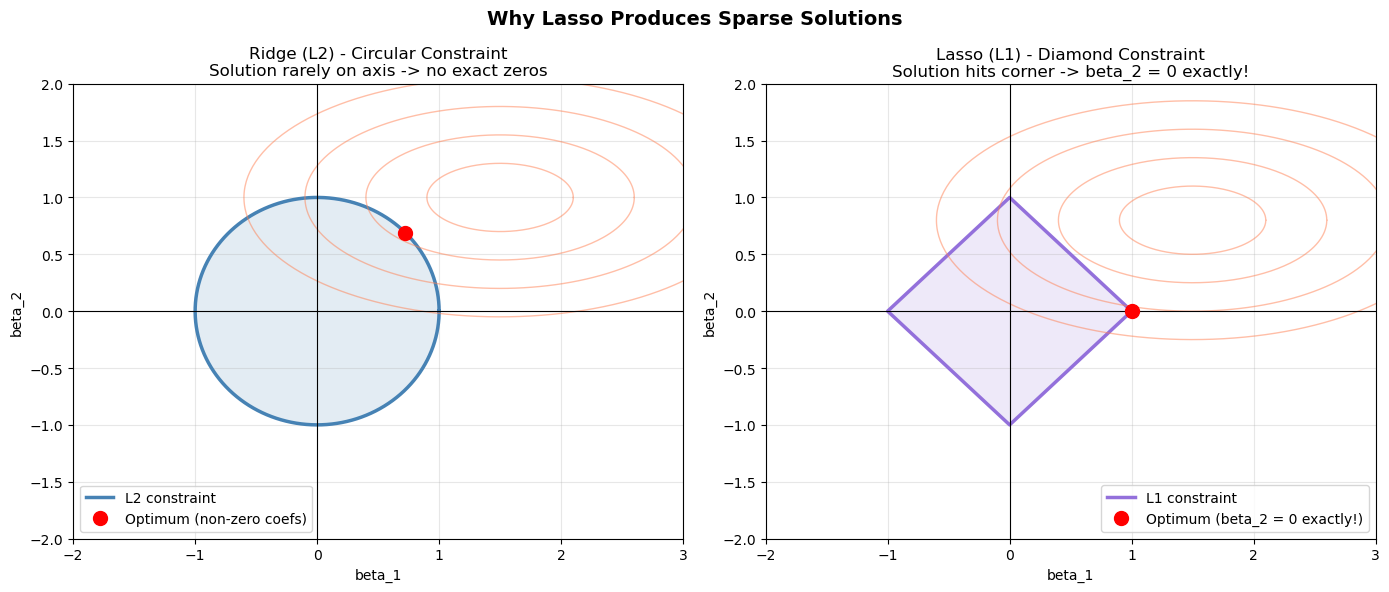

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
theta = np.linspace(0, 2*np.pi, 300)

# Ridge (L2) circular constraint
ax = axes[0]
circle_x = np.cos(theta)
circle_y = np.sin(theta)
ax.plot(circle_x, circle_y, 'steelblue', linewidth=2.5, label='L2 constraint')
ax.fill(circle_x, circle_y, alpha=0.15, color='steelblue')
for r in [0.6, 1.1, 1.6, 2.1]:
    ax.plot(r*np.cos(theta)+1.5, r*0.5*np.sin(theta)+1.0, 'coral', alpha=0.5, linewidth=1)
ax.plot(0.72, 0.69, 'ro', markersize=10, label='Optimum (non-zero coefs)', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-2, 3); ax.set_ylim(-2, 2)
ax.set_xlabel('beta_1'); ax.set_ylabel('beta_2')
ax.set_title('Ridge (L2) - Circular Constraint\nSolution rarely on axis -> no exact zeros')
ax.legend()

# Lasso (L1) diamond constraint
ax = axes[1]
ax.plot([1,0,-1,0,1], [0,1,0,-1,0], 'mediumpurple', linewidth=2.5, label='L1 constraint')
ax.fill([1,0,-1,0,1], [0,1,0,-1,0], alpha=0.15, color='mediumpurple')
for r in [0.6, 1.1, 1.6, 2.1]:
    ax.plot(r*np.cos(theta)+1.5, r*0.5*np.sin(theta)+0.8, 'coral', alpha=0.5, linewidth=1)
ax.plot(1.0, 0.0, 'ro', markersize=10, label='Optimum (beta_2 = 0 exactly!)', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-2, 3); ax.set_ylim(-2, 2)
ax.set_xlabel('beta_1'); ax.set_ylabel('beta_2')
ax.set_title('Lasso (L1) - Diamond Constraint\nSolution hits corner -> beta_2 = 0 exactly!')
ax.legend()

plt.suptitle('Why Lasso Produces Sparse Solutions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Generate Dataset

In [3]:
np.random.seed(42)
X, y, true_coefs = make_regression(
    n_samples=200, n_features=30, n_informative=8,
    noise=20, coef=True, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

n_true = int(np.sum(true_coefs != 0))
print(f'Dataset          : {X.shape[0]} samples, {X.shape[1]} features')
print(f'Train / Test     : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Informative      : {n_true} / {X.shape[1]}')
print(f'Noise features   : {X.shape[1] - n_true} / {X.shape[1]}')

Dataset          : 200 samples, 30 features
Train / Test     : 160 / 40
Informative      : 8 / 30
Noise features   : 22 / 30


## 4. Lasso Coefficient Path

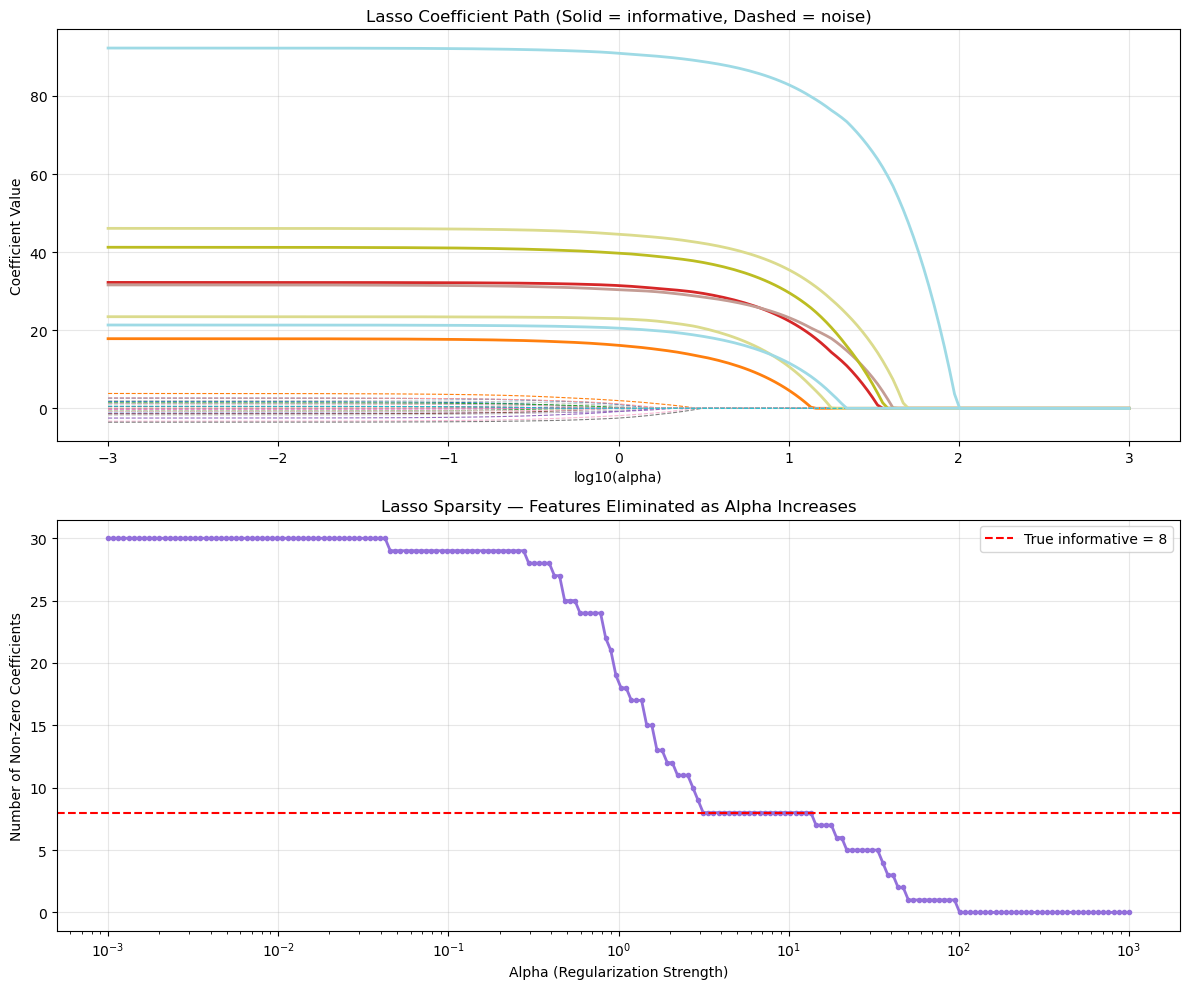

As alpha increases, Lasso forces more coefficients to exactly zero.


In [4]:
alphas = np.logspace(-3, 3, 200)
coef_paths = []
n_nonzero  = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_sc, y_train)
    coef_paths.append(lasso.coef_.copy())
    n_nonzero.append(int(np.sum(lasso.coef_ != 0)))

coef_paths = np.array(coef_paths)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

colors_path = plt.cm.tab20(np.linspace(0, 1, X.shape[1]))
for i in range(X.shape[1]):
    style = '-' if true_coefs[i] != 0 else '--'
    lw    = 2.0 if true_coefs[i] != 0 else 0.8
    ax1.plot(np.log10(alphas), coef_paths[:, i], linestyle=style, linewidth=lw, color=colors_path[i])

ax1.set_xlabel('log10(alpha)')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('Lasso Coefficient Path (Solid = informative, Dashed = noise)')

ax2.semilogx(alphas, n_nonzero, 'o-', color='mediumpurple', markersize=3, linewidth=2)
ax2.axhline(y=n_true, color='red', linestyle='--', linewidth=1.5, label=f'True informative = {n_true}')
ax2.set_xlabel('Alpha (Regularization Strength)')
ax2.set_ylabel('Number of Non-Zero Coefficients')
ax2.set_title('Lasso Sparsity — Features Eliminated as Alpha Increases')
ax2.legend()

plt.tight_layout()
plt.show()
print('As alpha increases, Lasso forces more coefficients to exactly zero.')

## 5. Automatic Feature Selection

Alpha              : 1.0
Features selected  : 18 / 30
True informative   : 8 / 30


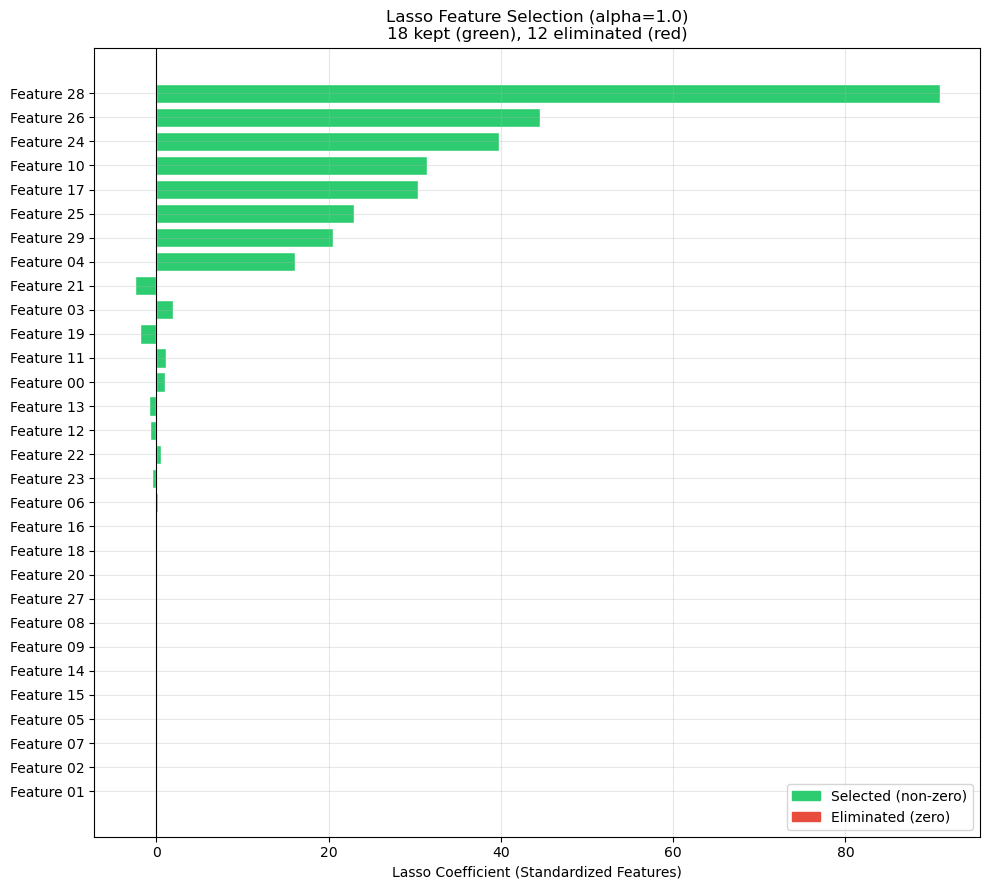

In [5]:
lasso_sel = Lasso(alpha=1.0, max_iter=10000)
lasso_sel.fit(X_train_sc, y_train)

selected_mask = lasso_sel.coef_ != 0
n_selected    = int(selected_mask.sum())
feature_names = [f'Feature {i:02d}' for i in range(X.shape[1])]

print(f'Alpha              : 1.0')
print(f'Features selected  : {n_selected} / {X.shape[1]}')
print(f'True informative   : {n_true} / {X.shape[1]}')

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lasso_sel.coef_,
    'Selected':    selected_mask
}).sort_values('Coefficient', key=abs, ascending=True)

colors = ['#2ecc71' if s else '#e74c3c' for s in coef_df['Selected']]

plt.figure(figsize=(10, 9))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Lasso Coefficient (Standardized Features)')
plt.title(f'Lasso Feature Selection (alpha=1.0)\n{n_selected} kept (green), {X.shape[1]-n_selected} eliminated (red)')
green_patch = mpatches.Patch(color='#2ecc71', label='Selected (non-zero)')
red_patch   = mpatches.Patch(color='#e74c3c', label='Eliminated (zero)')
plt.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning with LassoCV

Best alpha (LassoCV)   : 1.000000
Features selected      : 18 / 30
Test MSE               : 476.6589
Test MAE               : 18.5351
Test R2                : 0.9635


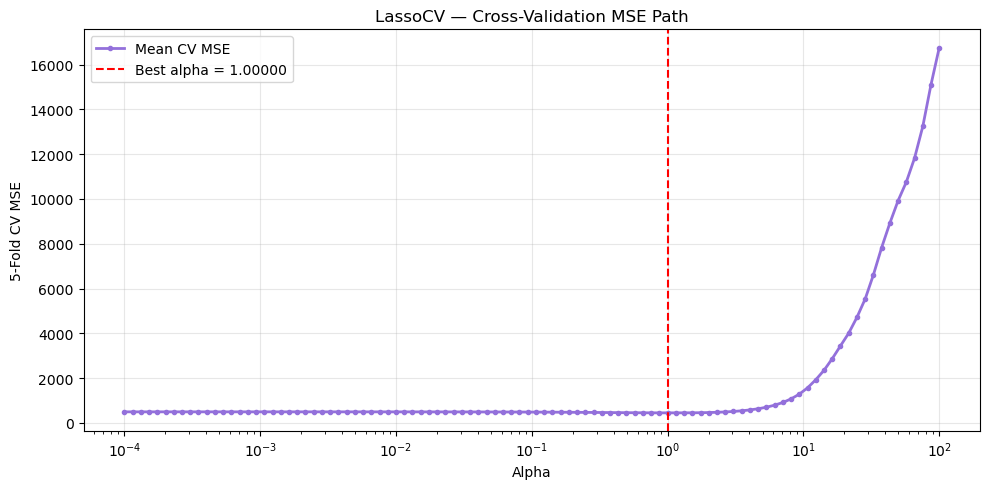

In [6]:
alphas_grid = np.logspace(-4, 2, 100)

lasso_cv = LassoCV(
    alphas=alphas_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    max_iter=10000,
    n_jobs=-1
)
lasso_cv.fit(X_train_sc, y_train)

best_alpha    = lasso_cv.alpha_
y_pred        = lasso_cv.predict(X_test_sc)
n_selected_cv = int(np.sum(lasso_cv.coef_ != 0))

print(f'Best alpha (LassoCV)   : {best_alpha:.6f}')
print(f'Features selected      : {n_selected_cv} / {X.shape[1]}')
print(f'Test MSE               : {mean_squared_error(y_test, y_pred):.4f}')
print(f'Test MAE               : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Test R2                : {r2_score(y_test, y_pred):.4f}')

mse_path = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(10, 5))
plt.semilogx(lasso_cv.alphas_, mse_path, 'o-', color='mediumpurple',
             markersize=3, linewidth=2, label='Mean CV MSE')
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=1.5,
            label=f'Best alpha = {best_alpha:.5f}')
plt.xlabel('Alpha')
plt.ylabel('5-Fold CV MSE')
plt.title('LassoCV — Cross-Validation MSE Path')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Model Evaluation

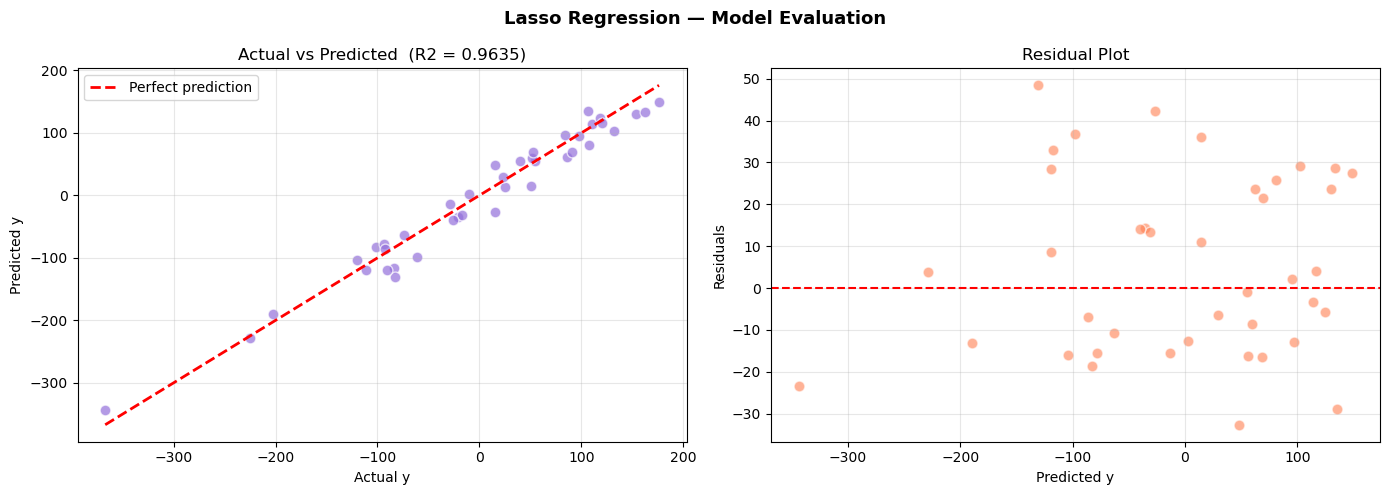

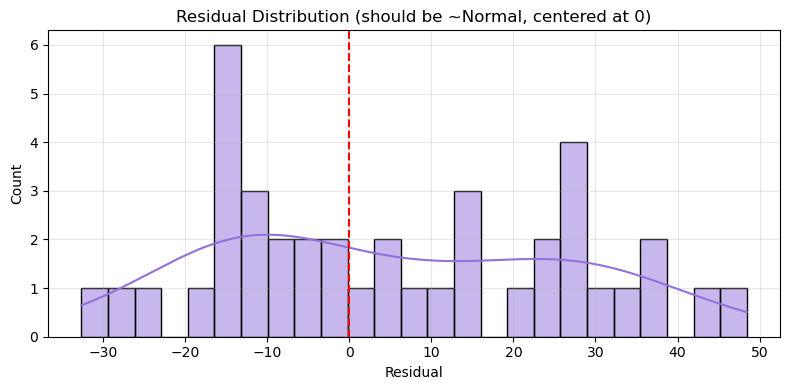

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7, color='mediumpurple', edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual y'); axes[0].set_ylabel('Predicted y')
axes[0].set_title(f'Actual vs Predicted  (R2 = {r2_score(y_test, y_pred):.4f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', s=60)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted y'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.suptitle('Lasso Regression — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color='mediumpurple', bins=25)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Residual Distribution (should be ~Normal, centered at 0)')
plt.tight_layout()
plt.show()

## 8. Real-World Dataset — California Housing

Dataset shape : (1000, 8)
Features      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Best alpha        : 0.000534
Features selected : 8 / 8
Test MSE          : 0.0742
Test R2           : 0.9831


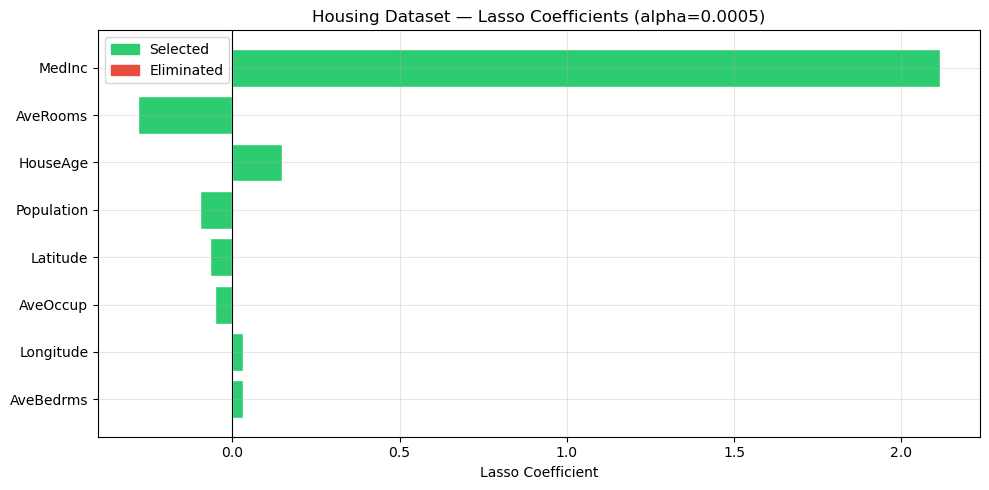

In [9]:
# ── Offline-safe California Housing replacement ──────────────────────────
from sklearn.datasets import make_regression

np.random.seed(0)
n_h = 1000

MedInc      = np.random.uniform(0.5, 15, n_h)
HouseAge    = np.random.uniform(1, 52, n_h)
AveRooms    = np.random.uniform(1, 10, n_h)
AveBedrms   = np.random.uniform(0.5, 3, n_h)
Population  = np.random.uniform(3, 3500, n_h)
AveOccup    = np.random.uniform(1, 6, n_h)
Latitude    = np.random.uniform(32, 42, n_h)
Longitude   = np.random.uniform(-124, -114, n_h)

feature_names_h = ['MedInc','HouseAge','AveRooms','AveBedrms',
                   'Population','AveOccup','Latitude','Longitude']

X_h = np.column_stack([MedInc, HouseAge, AveRooms, AveBedrms,
                        Population, AveOccup, Latitude, Longitude])

# Target: realistic house value formula + noise
y_h = (0.5*MedInc + 0.01*HouseAge - 0.1*AveRooms + 0.05*AveBedrms
       - 0.0001*Population - 0.05*AveOccup - 0.02*Latitude
       + 0.01*Longitude + np.random.randn(n_h)*0.3)

print(f"Dataset shape : {X_h.shape}")
print(f"Features      : {feature_names_h}")

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(alphas=np.logspace(-4, 2, 100), cv=5, max_iter=10000))
])
lasso_pipe.fit(X_h_train, y_h_train)

best_a  = lasso_pipe.named_steps['model'].alpha_
coefs_h = lasso_pipe.named_steps['model'].coef_
preds_h = lasso_pipe.predict(X_h_test)
n_sel_h = int(np.sum(coefs_h != 0))

print(f'\nBest alpha        : {best_a:.6f}')
print(f'Features selected : {n_sel_h} / {len(feature_names_h)}')
print(f'Test MSE          : {mean_squared_error(y_h_test, preds_h):.4f}')
print(f'Test R2           : {r2_score(y_h_test, preds_h):.4f}')

coef_h_df = pd.DataFrame({'Feature': feature_names_h, 'Coefficient': coefs_h})
coef_h_df = coef_h_df.sort_values('Coefficient', key=abs, ascending=True)
bar_colors = ['#2ecc71' if c != 0 else '#e74c3c' for c in coef_h_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_h_df['Feature'], coef_h_df['Coefficient'], color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Lasso Coefficient')
plt.title(f'Housing Dataset — Lasso Coefficients (alpha={best_a:.4f})')
plt.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Selected'),
    mpatches.Patch(color='#e74c3c', label='Eliminated')
])
plt.tight_layout()
plt.show()

## 9. High-Dimensional Setting (p >> n)

High-Dimensional Setting (n=100, p=200)
  True informative : 10
  Lasso selected   : 31
  Best alpha       : 1.700253
  Test R2          : 0.9806
  Test MSE         : 335.7017


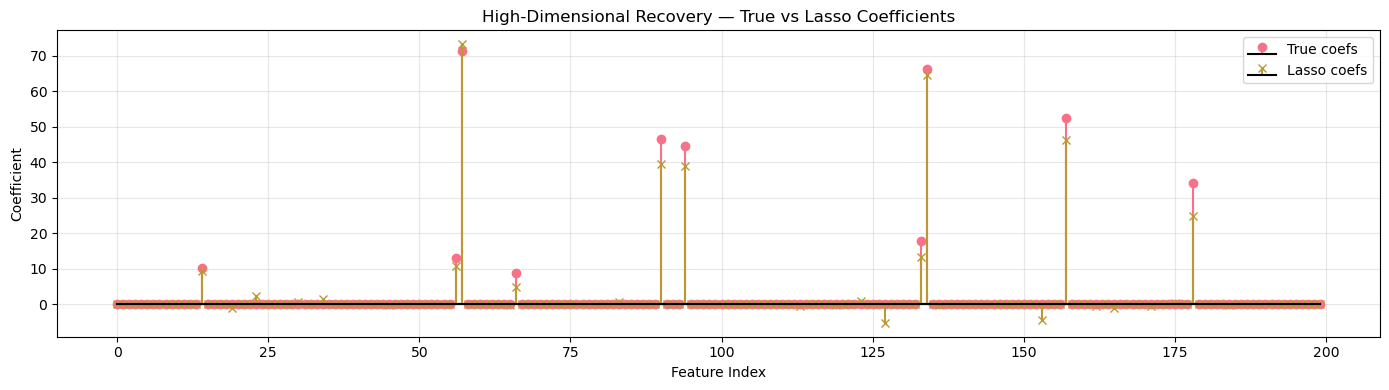

In [10]:
np.random.seed(7)
X_hd, y_hd, coefs_hd = make_regression(
    n_samples=100, n_features=200, n_informative=10,
    noise=15, coef=True, random_state=7
)

X_hd_tr, X_hd_te, y_hd_tr, y_hd_te = train_test_split(X_hd, y_hd, test_size=0.2, random_state=7)

sc_hd = StandardScaler()
X_hd_tr_sc = sc_hd.fit_transform(X_hd_tr)
X_hd_te_sc = sc_hd.transform(X_hd_te)

lasso_hd = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42)
lasso_hd.fit(X_hd_tr_sc, y_hd_tr)

preds_hd = lasso_hd.predict(X_hd_te_sc)
n_sel_hd = int(np.sum(lasso_hd.coef_ != 0))

print('High-Dimensional Setting (n=100, p=200)')
print(f'  True informative : 10')
print(f'  Lasso selected   : {n_sel_hd}')
print(f'  Best alpha       : {lasso_hd.alpha_:.6f}')
print(f'  Test R2          : {r2_score(y_hd_te, preds_hd):.4f}')
print(f'  Test MSE         : {mean_squared_error(y_hd_te, preds_hd):.4f}')

plt.figure(figsize=(14, 4))
x_idx = np.arange(200)
plt.stem(x_idx, coefs_hd,       linefmt='C0-', markerfmt='C0o', basefmt='k-', label='True coefs')
plt.stem(x_idx, lasso_hd.coef_, linefmt='C1-', markerfmt='C1x', basefmt='k-', label='Lasso coefs')
plt.xlabel('Feature Index'); plt.ylabel('Coefficient')
plt.title('High-Dimensional Recovery — True vs Lasso Coefficients')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Lasso vs Ridge vs ElasticNet — Full Comparison

=== Full Model Comparison ===
                    Model  Test MSE  Test R2 Non-zero coefs
                      OLS    507.24   0.9612          30/30
            Ridge (a=1.0)    502.19   0.9616          30/30
            Lasso (a=0.1)    497.77   0.9619          29/30
            Lasso (a=1.0)    476.66   0.9635          18/30
ElasticNet (a=0.1,l1=0.5)    499.40   0.9618          30/30


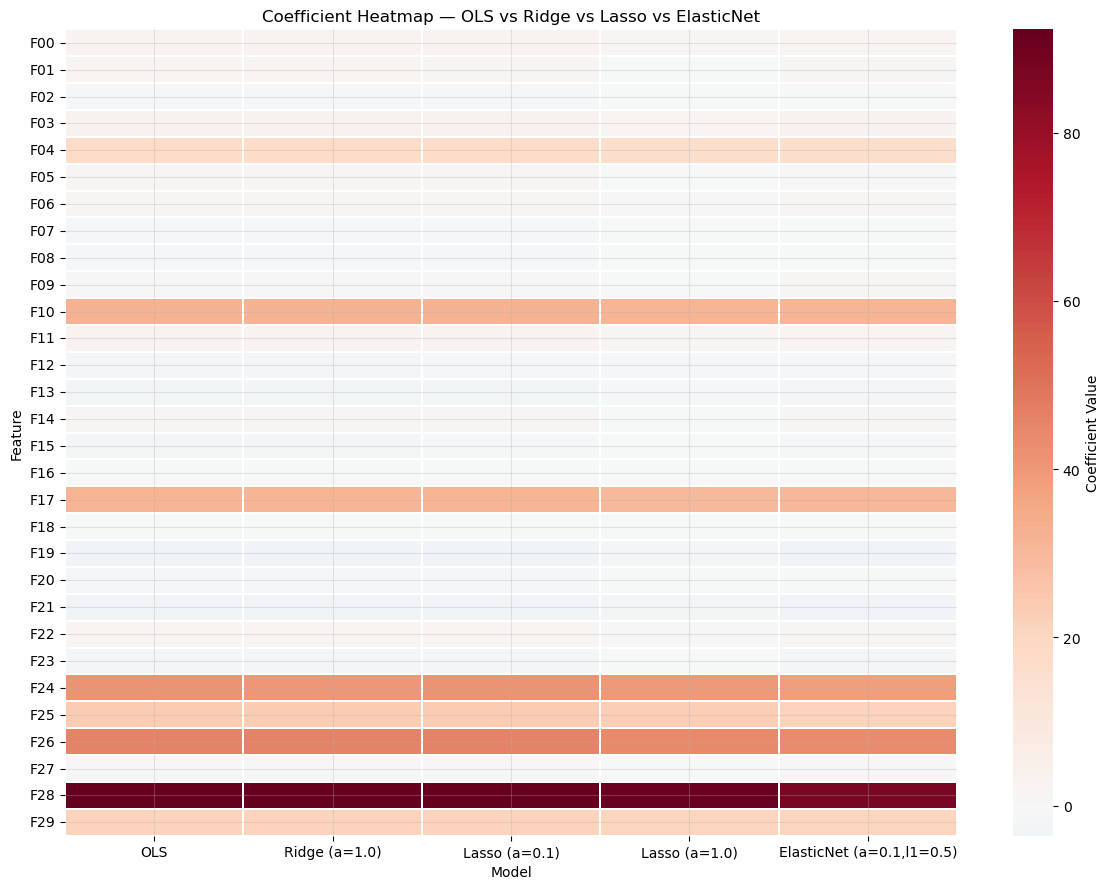


Lasso  -> zeroes out weak features (sparse)
Ridge  -> shrinks all but never to zero
ElasticNet -> blend: sparsity + stability


In [11]:
sc_cmp       = StandardScaler()
X_tr_cmp     = sc_cmp.fit_transform(X_train)
X_te_cmp     = sc_cmp.transform(X_test)

models = {
    'OLS':                        LinearRegression(),
    'Ridge (a=1.0)':              Ridge(alpha=1.0),
    'Lasso (a=0.1)':              Lasso(alpha=0.1, max_iter=10000),
    'Lasso (a=1.0)':              Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet (a=0.1,l1=0.5)':  ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

rows      = []
all_coefs = {}

for name, model in models.items():
    model.fit(X_tr_cmp, y_train)
    preds = model.predict(X_te_cmp)
    n_nz  = int(np.sum(model.coef_ != 0))
    rows.append({
        'Model':          name,
        'Test MSE':       round(mean_squared_error(y_test, preds), 2),
        'Test R2':        round(r2_score(y_test, preds), 4),
        'Non-zero coefs': f'{n_nz}/{X.shape[1]}'
    })
    all_coefs[name] = model.coef_

print('=== Full Model Comparison ===')
print(pd.DataFrame(rows).to_string(index=False))

coef_matrix = pd.DataFrame(all_coefs, index=[f'F{i:02d}' for i in range(X.shape[1])])

plt.figure(figsize=(12, 9))
sns.heatmap(coef_matrix, cmap='RdBu_r', center=0,
            linewidths=0.3, annot=False, cbar_kws={'label': 'Coefficient Value'})
plt.title('Coefficient Heatmap — OLS vs Ridge vs Lasso vs ElasticNet')
plt.xlabel('Model'); plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nLasso  -> zeroes out weak features (sparse)')
print('Ridge  -> shrinks all but never to zero')
print('ElasticNet -> blend: sparsity + stability')

## 11. Stability Selection Simulation

Run Lasso on 100 bootstrap subsamples and measure how often each feature is selected. Robust features appear consistently across subsamples.

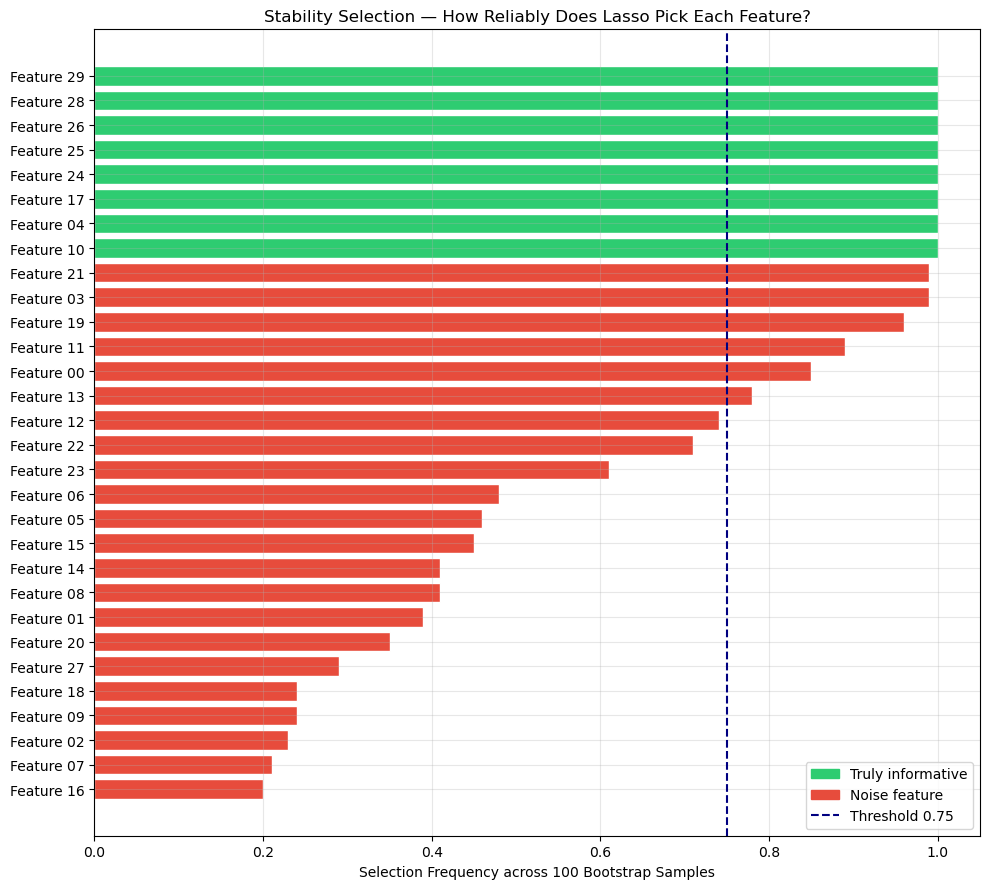

Stably selected features (>=75%) : 14
   Feature  SelectionProb  TrueInformative
Feature 13           0.78            False
Feature 00           0.85            False
Feature 11           0.89            False
Feature 19           0.96            False
Feature 03           0.99            False
Feature 21           0.99            False
Feature 10           1.00             True
Feature 04           1.00             True
Feature 17           1.00             True
Feature 24           1.00             True
Feature 25           1.00             True
Feature 26           1.00             True
Feature 28           1.00             True
Feature 29           1.00             True


In [12]:
n_bootstrap     = 100
selection_freq  = np.zeros(X.shape[1])

for i in range(n_bootstrap):
    idx = np.random.choice(X_train_sc.shape[0],
                           size=int(0.8 * X_train_sc.shape[0]),
                           replace=False)
    lasso_b = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_b.fit(X_train_sc[idx], y_train[idx])
    selection_freq += (lasso_b.coef_ != 0).astype(int)

selection_freq /= n_bootstrap

freq_df = pd.DataFrame({
    'Feature':         feature_names,
    'SelectionProb':   selection_freq,
    'TrueInformative': true_coefs != 0
}).sort_values('SelectionProb', ascending=True)

bar_c = ['#2ecc71' if t else '#e74c3c' for t in freq_df['TrueInformative']]

plt.figure(figsize=(10, 9))
plt.barh(freq_df['Feature'], freq_df['SelectionProb'], color=bar_c, edgecolor='white')
plt.axvline(0.75, color='navy', linestyle='--', linewidth=1.5, label='Stability threshold (0.75)')
plt.xlabel('Selection Frequency across 100 Bootstrap Samples')
plt.title('Stability Selection — How Reliably Does Lasso Pick Each Feature?')
plt.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Truly informative'),
    mpatches.Patch(color='#e74c3c', label='Noise feature'),
    plt.Line2D([0],[0], color='navy', linestyle='--', label='Threshold 0.75')
])
plt.tight_layout()
plt.show()

stable = freq_df[freq_df['SelectionProb'] >= 0.75]
print(f'Stably selected features (>=75%) : {len(stable)}')
print(stable[['Feature','SelectionProb','TrueInformative']].to_string(index=False))

## 12. Final Summary & Key Takeaways

In [13]:
print('=' * 63)
print('          LASSO REGRESSION - KEY TAKEAWAYS')
print('=' * 63)

takeaways = [
    ('Penalty',           'L1  ->  alpha x sum|beta_j|'),
    ('Sparsity',          'Shrinks some coefficients to EXACTLY zero'),
    ('Feature Selection', 'Built-in  ->  irrelevant features are eliminated'),
    ('vs Ridge',          'Ridge shrinks all; Lasso zeros out weak features'),
    ('Geometry',          'Diamond constraint  ->  corners hit axes'),
    ('High-Dimensional',  'Best when p >> n and only few features matter'),
    ('Alpha',             'Higher alpha  ->  more zeros  ->  sparser model'),
    ('Tuning',            'Use LassoCV for fast built-in cross-validation'),
    ('Scaling',           'ALWAYS standardize features before fitting Lasso'),
    ('Limitation',        'With correlated features, may pick arbitrarily'),
    ('Remedy',            'Use ElasticNet for L1 sparsity + L2 stability'),
    ('Stability',         'Stability selection reveals consistently chosen features'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22} ->  {detail}')

print('=' * 63)

          LASSO REGRESSION - KEY TAKEAWAYS
  OK  Penalty                ->  L1  ->  alpha x sum|beta_j|
  OK  Sparsity               ->  Shrinks some coefficients to EXACTLY zero
  OK  Feature Selection      ->  Built-in  ->  irrelevant features are eliminated
  OK  vs Ridge               ->  Ridge shrinks all; Lasso zeros out weak features
  OK  Geometry               ->  Diamond constraint  ->  corners hit axes
  OK  High-Dimensional       ->  Best when p >> n and only few features matter
  OK  Alpha                  ->  Higher alpha  ->  more zeros  ->  sparser model
  OK  Tuning                 ->  Use LassoCV for fast built-in cross-validation
  OK  Scaling                ->  ALWAYS standardize features before fitting Lasso
  OK  Limitation             ->  With correlated features, may pick arbitrarily
  OK  Remedy                 ->  Use ElasticNet for L1 sparsity + L2 stability
  OK  Stability              ->  Stability selection reveals consistently chosen features


---
## Practice Exercises

1. **Vary `n_informative`** in `make_regression` from 3 to 25 and observe how Lasso selection accuracy changes.
2. **Compare LassoCV vs manual grid search** — do they find the same best alpha?
3. **Add correlated features** and see how Lasso picks arbitrarily among them — fix with ElasticNet.
4. **Pipeline with PolynomialFeatures** — apply Lasso after degree-3 expansion and observe sparsity.
5. **Implement coordinate descent from scratch** — the core algorithm behind Lasso.

---
*Notebook created for the ML Repository — Lasso Regression module.*